# Изучение рынка заведений общественного питания Москвы

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных заведений общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить подходящие места для открытия заведения общественного питания в Москве.
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа используются данные о заведениях общественного питания Москвы. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
- `seats` — количество посадочных мест.


### Описание датасета `rest_price`

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
    - и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт..


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные bank_df и clients_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   str    
 1   name      8406 non-null   str    
 2   category  8406 non-null   str    
 3   address   8406 non-null   str    
 4   district  8406 non-null   str    
 5   hours     7870 non-null   str    
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 591.2 KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация об использовании клиентами услуг банка.

После первичного анализа данных можно сделать следующие выводы:

- Большинство представленных данных содержат текстовые значения и хранятся в типах данных `str`. Значения в столбцах `rating` и `seats` хранятся в типах данных `float64`, в столбце `chain` - `int64` и содержит значения 1 или 0 — размерность можно оптимизировать.
- Пропуски содержатся в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [5]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 158.6 KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания. По аналогии с предыдущим датасетом можно отметить, что:

- Типы данных соответствуют содержимому.
- Пропуски присутствуют во всех столбцах, кроме `id`.
- Значения в столбцах соответствуют описанию.

In [7]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, on='id', how = 'outer')

## 2. Предобработка данных

### 2.1. Оптимизируем типы данных


In [8]:
# Оптимизируем типы данных в датафрейме df
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [9]:
# Проверим типы данных в датафрейме df
df.dtypes

id                       str
name                     str
category                 str
address                  str
district                 str
hours                    str
rating               float64
chain                   int8
seats                float64
price                    str
avg_bill                 str
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

### 2.2. Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [10]:
# Применяем метод isna() к датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [11]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / info_df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме `df` обнаружено:
- 536 пропусков в столбце `hours` — это 6% данных - можно удалить.
- 3611 пропусков в столбце `seats` - это 43% данных, вероятно, при обработке данных произошел технический сбой либо данная информация не указана у заведения. Их можно заменить медианой по категории.
- 5091 пропусков в столбце `price` - это 61% данных, вероятно, при обработке данных произошел технический сбой либо данная информация не указана у заведения, оставим как есть.
- 4590 пропусков в столбце `avg_bill` - это 55% данных, вероятно, при обработке данных произошел технический сбой либо данная информация не указана у заведения, оставим как есть.
- 5257 пропусков в столбце `middle_avg_bill` - это 63% данных, значения указаны только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт», оставим как есть.
- 7871 пропусков в столбце `middle_coffee_cup` - это 94% данных, значения указаны только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино», оставим как есть.

In [12]:
# Удаляем строки с пропусками в hours
df = df.dropna(subset=['hours'])

In [13]:
# Считаем медиану для каждой категории
seats_median = df.groupby('category')['seats'].median().round()
print(seats_median)

category
бар,паб            82.0
булочная           50.0
быстрое питание    70.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           74.0
Name: seats, dtype: float64


In [14]:
# Заполняем пропуски
for cat in seats_median.index:
    df.loc[(df['category'] == cat) & (df['seats'].isna()), 'seats'] = seats_median[cat]

In [15]:
# Так как теперь в столбце seats целочисленные значения и нет пропусков, преобразуем тип данных
df['seats'] = pd.to_numeric(df['seats'], downcast='integer')

In [16]:
# Проверяем пропуски в датафрейме df после обработки
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                   0
price                4560
avg_bill             4062
middle_avg_bill      4727
middle_coffee_cup    7336
dtype: int64

### 2.3. Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [19]:
# Нормализуем данные в столбце с названием заведения
df['name'] = (df['name'].str.lower().str.strip())
df['address'] = (df['address'].str.lower().str.strip())

In [20]:
# Проверяем полные дубликаты в датафрейме
df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты:

In [21]:
# Проверяем неявные дубликаты в датафрейме по id
df.duplicated(subset='id').sum()

np.int64(0)

In [22]:
# Проверяем неявные дубликаты по названию заведения и его адресу
duplicates = df[df.duplicated(subset=['name', 'address'], keep=False)]
print(duplicates[['name', 'address']])

                           name                                  address
211                        кафе             москва, парк ангарские пруды
3205                  more poke  москва, волоколамское шоссе, 11, стр. 2
4466                       кафе             москва, парк ангарские пруды
5432                  more poke  москва, волоколамское шоссе, 11, стр. 2
5580  раковарня клешни и хвосты               москва, проспект мира, 118
6474  раковарня клешни и хвосты               москва, проспект мира, 118


In [23]:
# Удалим неявные дубликаты
df = df.drop_duplicates(subset=['name', 'address'], keep='first')

In [24]:
# Проверим корректность написания категориальных значений в данных
for column in ['category', 'district', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique().tolist())
    print()

Уникальные значения в столбце category:
['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ', 'Западный административный округ', 'Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Центральный административный округ', 'Юго-Восточный административный округ', 'Юго-Западный административный округ', 'Южный административный округ']

Уникальные значения в столбце price:
['высокие', 'выше среднего', 'низкие', 'средние', nan]



В категориальных значениях также нет ошибок.

### 2.4. Новый столбец

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7

In [28]:
df['is_24_7'] = df['hours'].isin(['ежедневно, круглосуточно',
                                  '24/7',
                                  'ежедневно, 00:00-23:59',
                                  'ежедневно, 00:00-00:00'])

### 2.5. Промежуточные выводы после предобработки

В результате предобработки данных были выполнены следующие действия:

- Оптимизирован тип данных в столбце `chain`.
- Изучены пропуски в данных. Пропуски обнаружились в столбце  `hours` - их было около 6% (536 строк), поэтому они были удалены; в столбце `seats` - около 46%, их мы заполнили медианой по категориям; в остальных столбцах пропуски были оставлены как есть.
- Данные проверили на явные и неявные дубликаты, было найдено и удалено 2 неявных дубликата.

In [29]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.DataFrame'>
Index: 7867 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7867 non-null   str    
 1   name               7867 non-null   str    
 2   category           7867 non-null   str    
 3   address            7867 non-null   str    
 4   district           7867 non-null   str    
 5   hours              7867 non-null   str    
 6   rating             7867 non-null   float64
 7   chain              7867 non-null   int8   
 8   seats              7867 non-null   int16  
 9   price              3310 non-null   str    
 10  avg_bill           3808 non-null   str    
 11  middle_avg_bill    3143 non-null   float64
 12  middle_coffee_cup  534 non-null    float64
 13  is_24_7            7867 non-null   bool   
dtypes: bool(1), float64(3), int16(1), int8(1), str(8)
memory usage: 768.3 KB


Теперь датафрейм содержит 14 столбцов и 7867 строк и готов к анализу.

## 3. Исследовательский анализ данных

### 3.1. Распределение заведений по категориям

In [31]:
print(df['category'].value_counts())

category
кафе               2002
ресторан           1967
кофейня            1398
бар,паб             747
пиццерия            628
быстрое питание     570
столовая            306
булочная            249
Name: count, dtype: int64


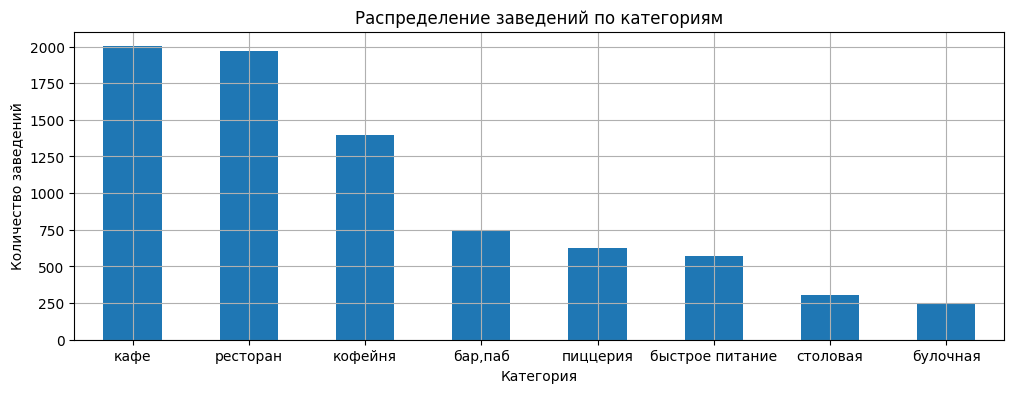

In [33]:
df['category'].value_counts().plot.bar(title = 'Распределение заведений по категориям',
            legend = False,
            rot = 0,
            figsize = (12, 4))
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

**Вывод**: всего представлено 8 категорий заведения:
- больше всего заведений в категориях "кафе" и "ресторан" - 2002 и 1967 заведений соответственно.
- меньше всего - в категориях "столовая" и "булочная" - 306 и 249 соответственно.

### 3.2. Распределение заведений по административным районам

In [35]:
# Заменим названия административных районов на сокращения для удобства визуализации
district_names = {
    'Центральный административный округ': 'ЦАО',
    'Северный административный округ': 'САО',
    'Северо-Восточный административный округ': 'СВАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Южный административный округ': 'ЮАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Западный административный округ': 'ЗАО',
    'Северо-Западный административный округ': 'СЗАО'
}
df['district'] = df['district'].replace(district_names)

In [36]:
print(df['district'].value_counts())

district
ЦАО     2211
САО      844
СВАО     829
ЮАО      827
ЗАО      785
ВАО      723
ЮЗАО     650
ЮВАО     629
СЗАО     369
Name: count, dtype: int64


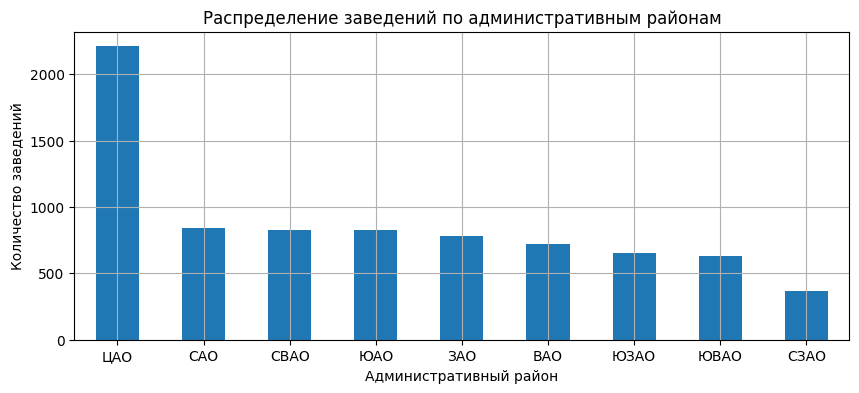

In [40]:
df['district'].value_counts().plot.bar(title = 'Распределение заведений по административным районам',
                                       legend = False,
                                       rot = 0,
                                       figsize = (10, 4))
plt.xlabel('Административный район')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

**Вывод**: Больше всего заведений находится в ЦАО (2211), меньше всего - в СЗАО (369), остальные заведения распределены по оставшимся административным районам равномерно.

In [38]:
df_cao = df[df['district'] == 'ЦАО']
category_cao = df_cao['category'].value_counts()
print(category_cao)

category
ресторан           665
кафе               444
кофейня            426
бар,паб            364
пиццерия           112
быстрое питание     85
столовая            65
булочная            50
Name: count, dtype: int64


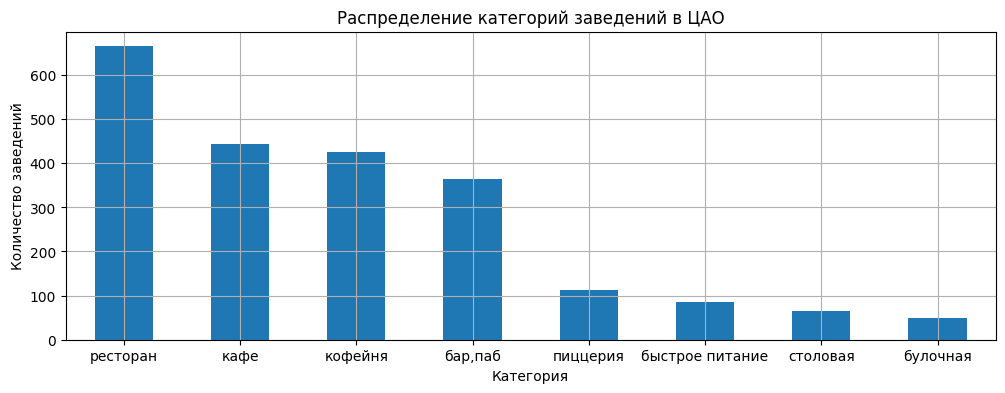

In [41]:
category_cao.plot.bar(title = 'Распределение категорий заведений в ЦАО',
                      legend = False,
                      rot = 0,
                      figsize = (12, 4))
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

**Вывод**: В ЦАО больше всего ресторанов (665), меньше всего быстрого питания, столовых и булочных (85, 65 и 50 соответственно).

### 3.3. Анализ сетевых и несетевых заведений

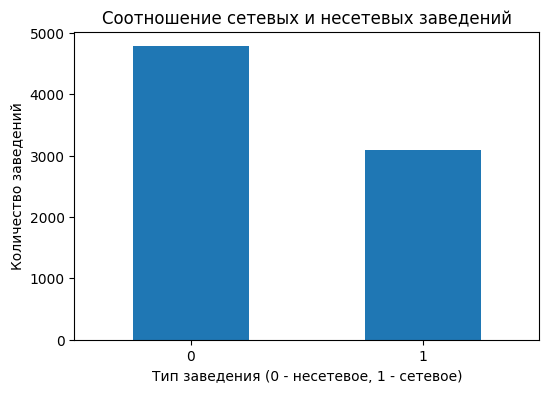

In [42]:
df['chain'].value_counts().plot.bar(title='Соотношение сетевых и несетевых заведений',
                                    legend=False,
                                    rot=0,
                                    figsize=(6, 4))
plt.xlabel('Тип заведения (0 - несетевое, 1 - сетевое)')
plt.ylabel('Количество заведений')
plt.show()

In [43]:
print(f"Доля сетевых заведений - {df['chain'].mean()*100:.1f}%")
print(f"Доля несетевых заведений - {100 - df['chain'].mean()*100:.1f}%")

Доля сетевых заведений - 39.3%
Доля несетевых заведений - 60.7%


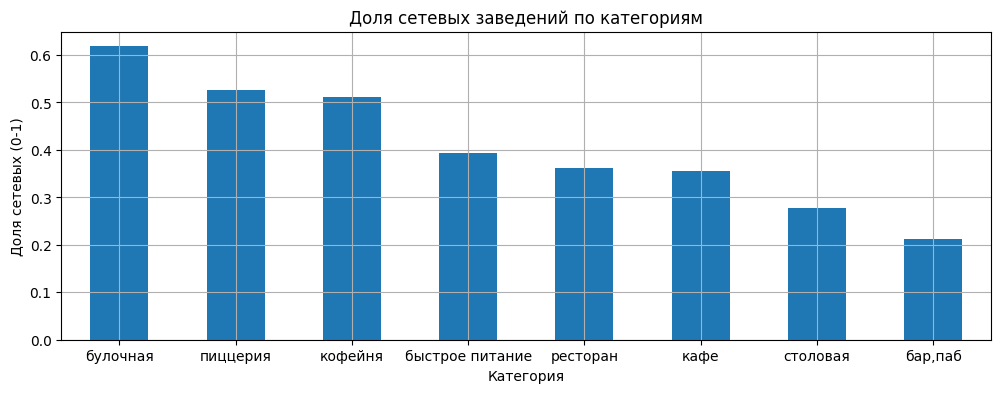

In [67]:
df.groupby('category')['chain'].mean().sort_values(ascending=False).plot.bar(title='Доля сетевых заведений по категориям',
                                                rot=0,
                                                figsize=(12, 4))
plt.xlabel('Категория')
plt.ylabel('Доля сетевых (0-1)')
plt.grid()
plt.show()

In [47]:
df.groupby('category')['chain'].mean().sort_values(ascending=False).round(2)*100

category
булочная           62.0
пиццерия           53.0
кофейня            51.0
быстрое питание    39.0
ресторан           36.0
кафе               36.0
столовая           28.0
бар,паб            21.0
Name: chain, dtype: float64

**Вывод**: В целом по Москве преобладают несетевые заведения (60.7%). Среди категорий самая высокая доля сетевых у булочных (62%), пиццерий (53%) и кофеен (51%).

### 3.4. Анализ посадочных мест в заведениях

In [48]:
df['seats'].describe()

count    7867.000000
mean       92.587517
std        92.117157
min         0.000000
25%        55.000000
50%        75.000000
75%        86.000000
max      1288.000000
Name: seats, dtype: float64

Text(0.5, 1.0, 'Количество посадочных мест')

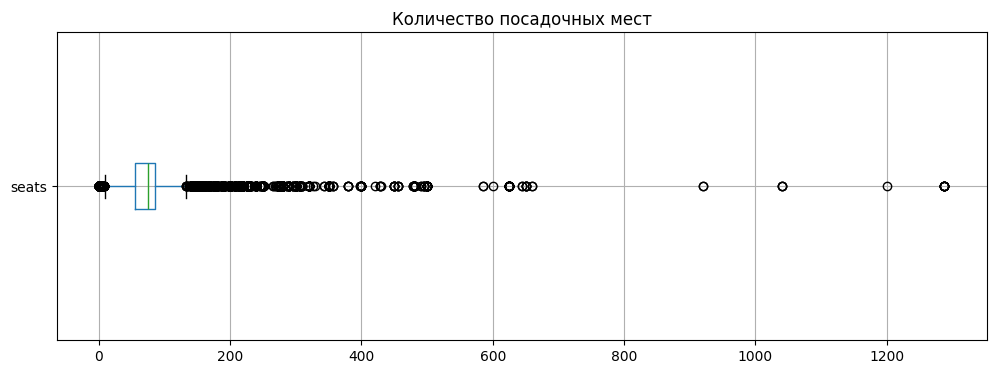

In [49]:
df.boxplot(column='seats',
           vert=False,
           grid=True,
           figsize=(12,4))
plt.title('Количество посадочных мест')

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           74.0
быстрое питание    70.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64


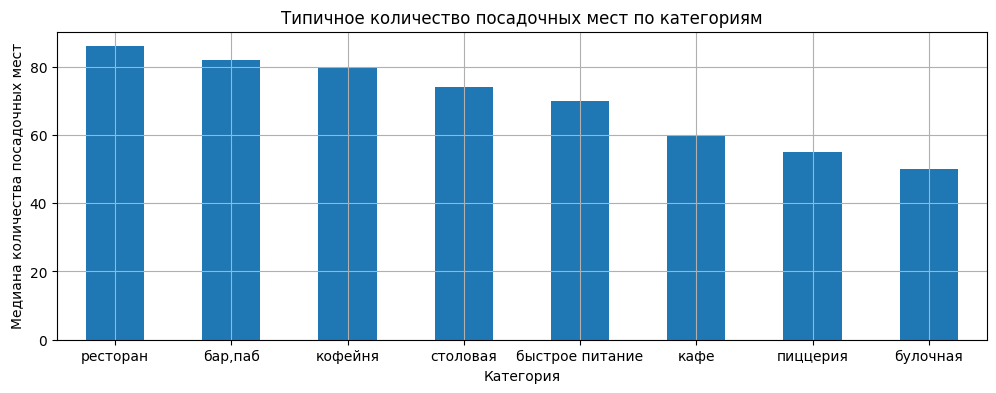

In [71]:
print(df.groupby('category')['seats'].median().round().sort_values(ascending=False))

df.groupby('category')['seats'].median().round().sort_values(ascending=False).plot.bar(title='Типичное количество посадочных мест по категориям',
                                                rot=0,
                                                figsize=(12, 4))
plt.xlabel('Категория')
plt.ylabel('Медиана количества посадочных мест')
plt.grid()
plt.show()

**Вывод**:
- выбросы обнаружены: максимальное значение достигает 1288 мест, что значительно превышает верхнюю границу усов (~170 мест) - это могут быть банкетные залы ресторанов или ошибки в данных.
- минимум равен 0 — вероятно, заведения без посадочных мест (формат "на вынос") или ошибки в данных.

Типичное количество мест (медиана) по категориям:
- ресторан — 86 мест
- бар, паб — 82 места
- кофейня — 80 мест
- столовая — 74 места
- быстрое питание — 70 мест
- кафе — 60 мест
- пиццерия — 55 мест
- булочная — 50 мест

### 3.5. Анализ рейтинга заведений

In [51]:
df['rating'].describe()

count    7867.000000
mean        4.244299
std         0.452896
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.30
булочная           4.28
кофейня            4.28
столовая           4.22
кафе               4.15
быстрое питание    4.06
Name: rating, dtype: float64


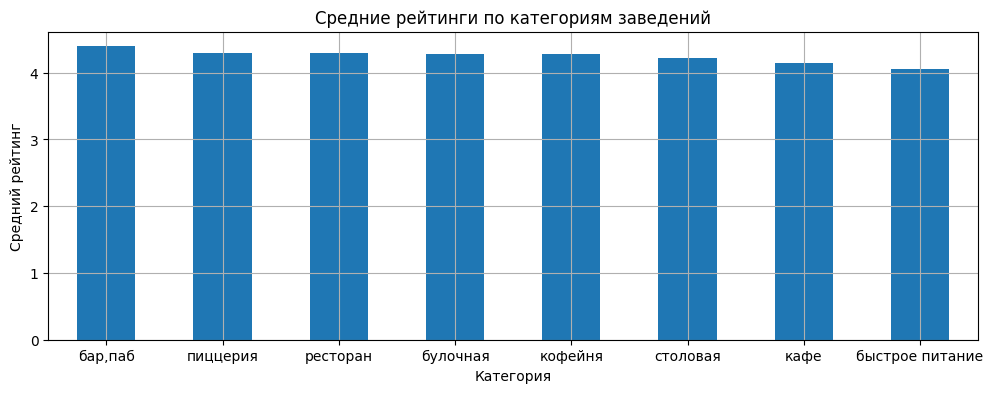

In [73]:
print(df.groupby('category')['rating'].mean().sort_values(ascending=False).round(2))

df.groupby('category')['rating'].mean().sort_values(ascending=False).plot.bar(title='Средние рейтинги по категориям заведений',
                                                 rot=0,
                                                 figsize=(12,4))
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.grid()
plt.show()

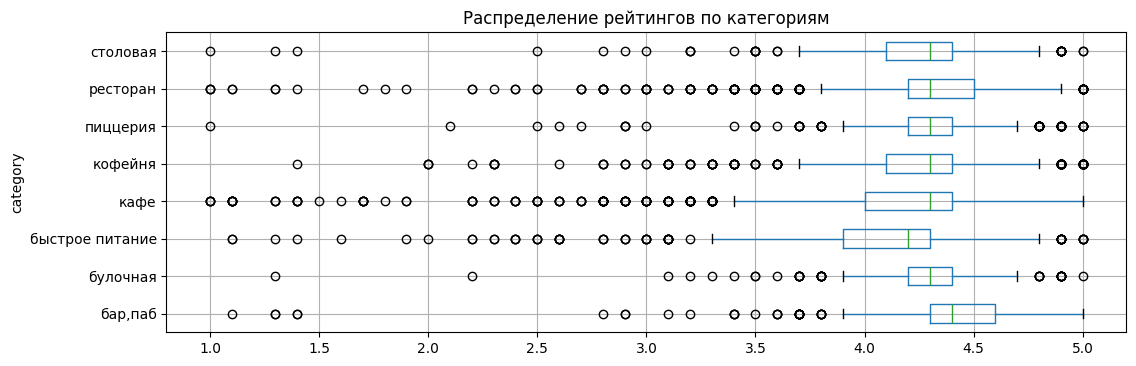

In [53]:
df.boxplot(column='rating',
           by='category',
           rot=0,
           figsize=(12, 4),
           vert=False,
           grid=True)
plt.title('Распределение рейтингов по категориям')
plt.suptitle('')
plt.show()

**Вывод**:
- средние рейтинги категорий находятся в диапазоне от 4.0 до 4.5
- разброс между самым высоким и самым низким ретингом - 0.33
- самый высокий усредненный рейтинг в категории "бар, паб" - 4.39
- самый низкий усредненный рейтинг в категории "быстрое питание" - 4.06

### 3.6. Корелляция рейтинга заведений с разными признаками¶

In [54]:
correlation_matrix = df[['rating','district', 'category', 'chain', 'seats', 'price','is_24_7']].phik_matrix()
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220942
district,0.197175
category,0.178342
is_24_7,0.174880
chain,0.114381
seats,0.000000


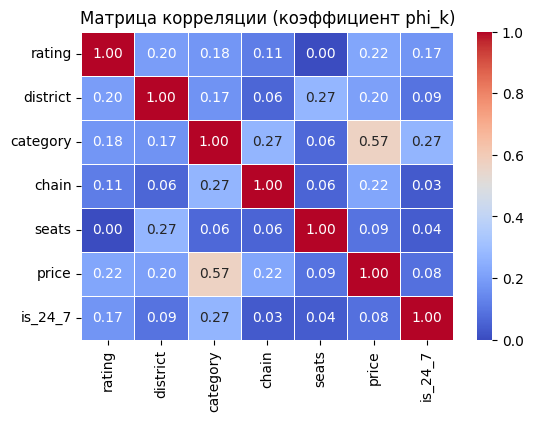

In [55]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,)
plt.title('Матрица корреляции (коэффициент phi_k)')
plt.show()

In [56]:
# Корреляция между middle_avg_bill и rating (только там, где есть данные)
avg_bill_clean = df[['middle_avg_bill', 'rating']].dropna()
print(avg_bill_clean['middle_avg_bill'].corr(avg_bill_clean['rating'], method='spearman'))

0.36427490917764405


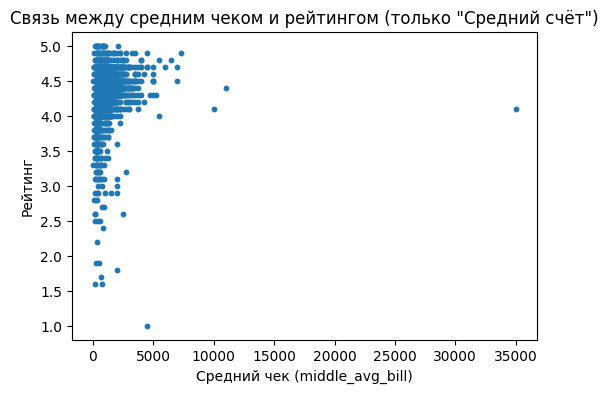

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(avg_bill_clean['middle_avg_bill'],
            avg_bill_clean['rating'],
            s=10)
plt.xlabel('Средний чек (middle_avg_bill)')
plt.ylabel('Рейтинг')
plt.title('Связь между средним чеком и рейтингом (только "Средний счёт")')
plt.show()

**Вывод**:
- при расчете корреляции с помощью коэффициента phi_k самая сильная связь выявлена между рейтингом и ценовой категорией заведения (0.22)
- далее посчитали корреляцию с помощью коэффициента Спирмана между рейтингом и средним чеком (только для тех заведений, где он указан - 3143 заведения) - 0.36 - умеренная положительная связь
- в среднем заведения с более высоким чеком имеют более высокий рейтинг, однако связь не очень сильная — на рейтинг влияют и другие факторы

### 3.7. Топ-15 популярный сетей в Москве

In [58]:
top_chains = df[df['chain'] == 1]['name'].value_counts().head(15)
print(top_chains)

name
шоколадница                            120
домино'с пицца                          76
додо пицца                              74
one price coffee                        71
яндекс лавка                            68
cofix                                   65
prime                                   50
кофепорт                                42
кулинарная лавка братьев караваевых     39
хинкальная                              39
теремок                                 38
cofefest                                32
буханка                                 31
чайхана                                 29
му-му                                   27
Name: count, dtype: int64


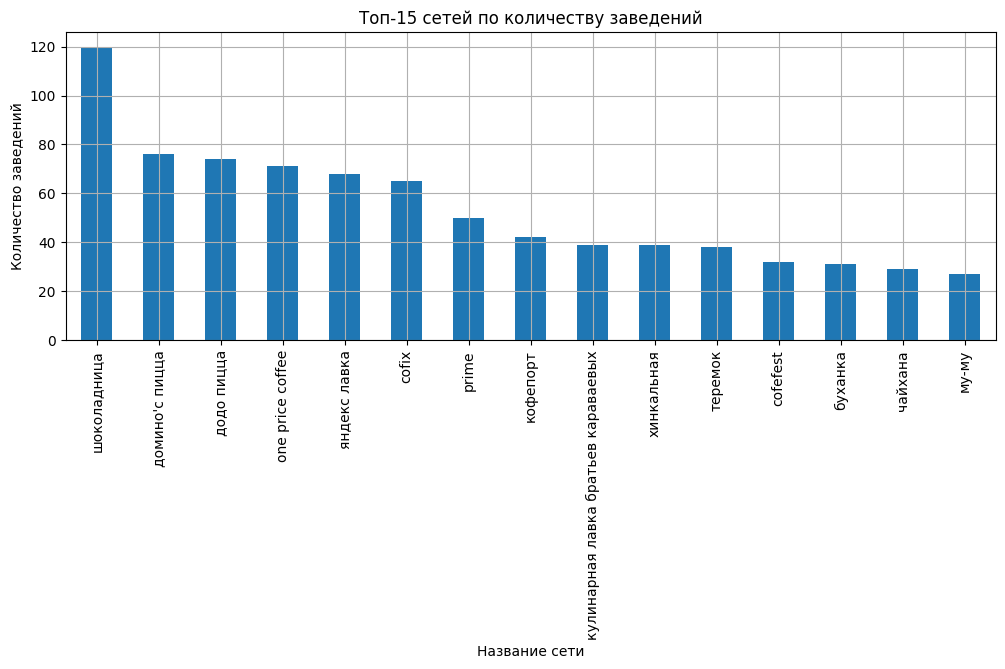

In [75]:
top_chains.plot.bar(title='Топ-15 сетей по количеству заведений',
                    figsize=(12, 4))
plt.xlabel('Название сети')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

In [60]:
top_chains_df = top_chains.reset_index()
top_chains_df.columns = ['name', 'count']
merged = df[df['chain'] == 1].merge(top_chains_df[['name']], on='name')
summary = merged.groupby('name').agg(количество=('name', 'count'),
                                     средний_рейтинг=('rating', 'mean'),
                                     категория=('category', 'first')).sort_values('количество', ascending=False)
print(summary)

                                     количество  средний_рейтинг категория
name                                                                      
шоколадница                                 120         4.177500   кофейня
домино'с пицца                               76         4.169737  пиццерия
додо пицца                                   74         4.286486  пиццерия
one price coffee                             71         4.064789   кофейня
яндекс лавка                                 68         3.870588  ресторан
cofix                                        65         4.075385   кофейня
prime                                        50         4.116000  ресторан
кофепорт                                     42         4.147619   кофейня
кулинарная лавка братьев караваевых          39         4.394872      кафе
хинкальная                                   39         4.374359  ресторан
теремок                                      38         4.123684  ресторан
cofefest                 

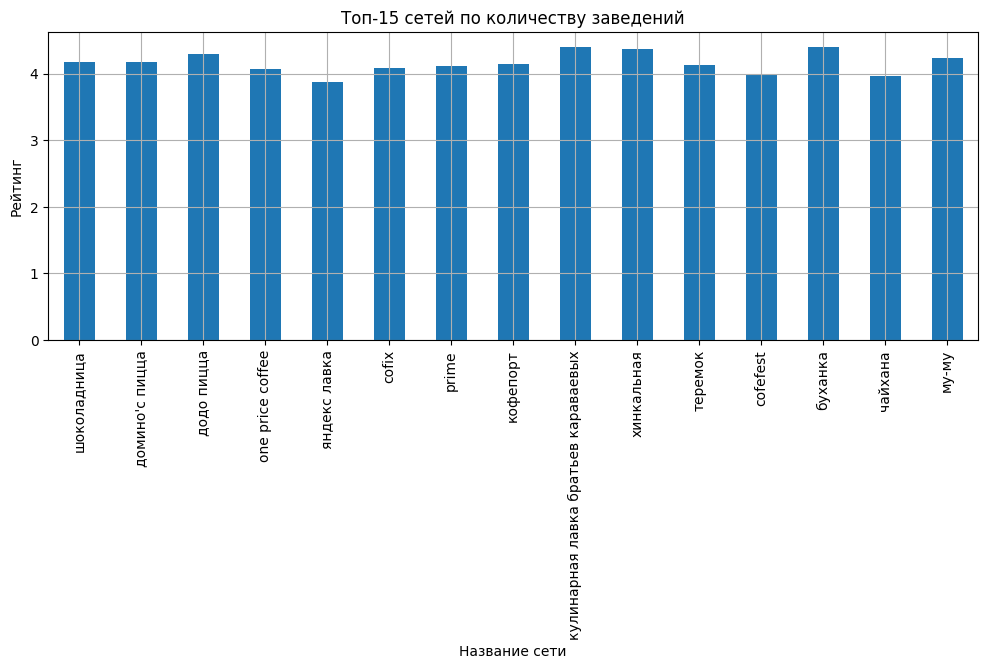

In [78]:
summary.plot.bar(title='Топ-15 сетей по количеству заведений',
                 y='средний_рейтинг',
                 legend=False,
                 figsize=(12, 4))
plt.xlabel('Название сети')
plt.ylabel('Рейтинг')
plt.grid()
plt.show()

**Вывод**:
- сетевое заведение с самым большим количеством точек - Шоколадница (120 точек, кофейня, средний рейтинг 4.18)
- сетевое заведение с самым маленьким количеством точек (среди топ-15) - Му-му (27 точек, кафе, средний рейтинг 4.23)
- самый высокий средний рейтинг - у Буханки (31 точка, булочная, средний рейтинг 4.4)
- самый низкий рейтинг - у Яндекс лавки (68 точек, ресторан, средний рейтинг 3.87)

### 3.8. Анализ среднего чека заведения в зависимости от района Москвы

In [62]:
df_bill = df[['middle_avg_bill', 'district']].dropna()
bill_by_district = df_bill.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)
print(bill_by_district)

district
ЦАО     1190.559130
ЗАО     1053.072131
САО      927.959627
ЮАО      836.301282
СЗАО     822.222930
ВАО      820.626923
ЮЗАО     792.561702
СВАО     716.611296
ЮВАО     654.097938
Name: middle_avg_bill, dtype: float64


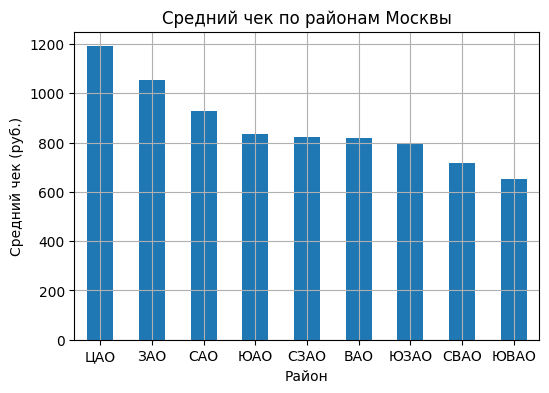

In [80]:
bill_by_district.plot.bar(title='Средний чек по районам Москвы',
                          figsize=(6, 4),
                          rot=0)
plt.xlabel('Район')
plt.ylabel('Средний чек (руб.)')
plt.grid()
plt.show()

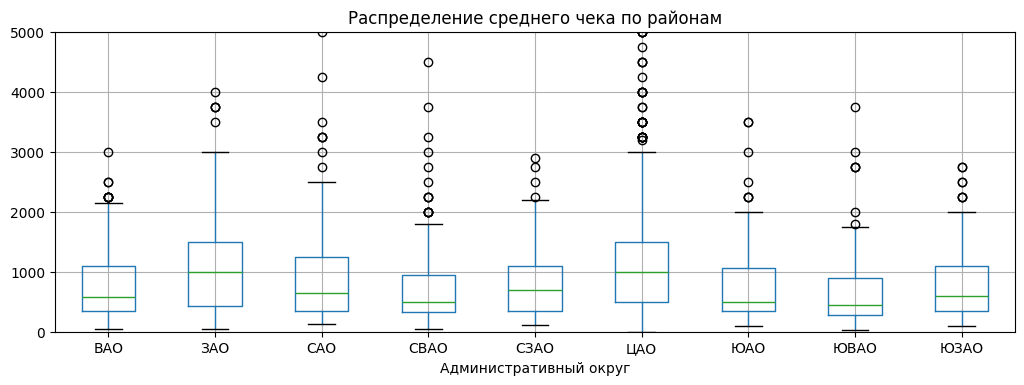

In [64]:
df_bill.boxplot(column='middle_avg_bill',
                by='district',
                rot=0,
                figsize=(12, 4))
plt.suptitle('')
plt.title('Распределение среднего чека по районам')
plt.xlabel('Административный округ')
plt.ylim(0, 5000)
plt.show()

**Вывод**:
- самый высокий средний чек - в ЦАО (1191 руб.)
- самый низкий средний чек - в ЮЗАО (793 руб.), СВАО (717 руб.) и ЮВАО (654 руб.)
- наблюдается закономерность: чем дальше от центра, тем ниже средний чек заведений

## 4. Итоговый вывод и рекомендации

### 4.1. Общий обзор проделанной работы

В ходе исследования был проведён анализ рынка общественного питания Москвы на основе данных сервисов Яндекс Карты и Яндекс Бизнес (лето 2022 года). Исходные данные содержали информацию о 8405 заведениях. В процессе подготовки данных были выполнены следующие операции:
- очистка данных: удалены строки с пропусками в столбце `hours` (536 строк, 6% данных), удалены выявленные 3 неявных дубликата по паре «название + адрес».
- заполнение пропусков: для столбца `seats` (43% пропусков) пропуски заполнили медианными значениями по категориям заведений.
- преобразование типов: столбец `seats` приведён к целочисленному типу `int16`, создан бинарный признак `is_24_7` для заведений, работающих ежедневно и круглосуточно.
- нормализация данных: проведена нормализация названий административных районов (введены краткие обозначения) и названий заведений для поиска дубликатов.

Итоговый датафрейм содержит 7867 заведений с 14 признаками.

### 4.2. Ответы на исследовательские вопросы

1. **Категории заведений:**
В Москве представлено 8 категорий общепита. Лидеры по количеству — «кафе» (2002) и «ресторан» (1967). Наименее распространены «столовая» (306) и «булочная» (249).

2. **Административные районы:**
Больше всего заведений сосредоточено в ЦАО (2211). Наименьшее количество — в СЗАО (369). В ЦАО преобладают «рестораны» (665), тогда как в целом по городу лидируют «кафе». Это говорит о более высокой концентрации дорогих и статусных заведений в центре.

3. **Сетевые и несетевые заведения:**
В Москве преобладают несетевые заведения (доля сетевых — около 39%). Среди категорий самая высокая доля сетевых — у «булочных», «пиццерий» и «кофеен».

4. **Посадочные места:**
Выявлены выбросы — заведения с количеством мест более 170 (максимум 1288). Типичная вместимость (медиана): ресторан — 86 мест, бар/паб — 82 места, кофейня — 80 мест, столовая — 74 места, быстрое питание - 70 мест, кафе — 60 мест, пиццерия - 55 мест, булочная — 50 мест.

5. **Рейтинг заведений:**
Средние рейтинги по категориям находятся в диапазоне 4.06–4.39 (разница 0.33). Самый высокий средний рейтинг — у «бар/паб» (4.39), самый низкий — у «быстрое питание» (4.06). В целом все категории имеют стабильно высокие оценки.

6. **Корреляция рейтинга с признаками:**
- средний чек (middle_avg_bill) показывает умеренную положительную корреляцию с рейтингом (коэффициент 0.36).
- ценовая категория (price) — слабая связь (0.22).
- с остальными признаками корреляционная связь незначительна.

7. **Топ-15 популярных сетей:**
Крупнейшая сеть — «Шоколадница» (120 точек, кофейня, рейтинг 4.18). Самый высокий средний рейтинг среди топ-15 — у «Буханки» (4.40, 31 точка, булочная), самый низкий — у «Яндекс Лавки» (3.87, 68 точек, ресторан).

8. **Средний чек по районам:**
- самый высокий — в ЦАО (1190 руб.)
- самый низкий — в ЮВАО (654 руб.), СВАО (716 руб.), ЮЗАО (792 руб.)
- закономерность: чем дальше от центра, тем ниже средний чек.

### 4.3. Рекомендации на основе анализа данных

1. **Выбор района:**
- для высокого чека предпочтительно открывать заведение в ЦАО - здесь максимальный средний чек, но и аренда будет выше
- для минимальной конкуренции лучше открывать заведение в ЮВАО, СВАО или ЮЗАО - здесь меньше всего заведений, но самый низкий средний чек

2. **Выбор формата заведения:**
- наиболее перспективные категории с точки зрения доли сетей и среднего рейтинга: кофейни и пиццерии
- булочные имеют высокую долю сетевых и высокий рейтинг, но абсолютное количество заведений мало
- бары и пабы имеют самый высокий рейтинг среди всех категорий

3. **Ценовая стратегия:**
- прямая связь между средним чеком и рейтингом (коэффициент 0.36) говорит о том, что повышение цен должно сопровождаться качеством
- в спальных районах целевая аудитория более чувствительна к ценам — рекомендуется средний чек в диапазоне 650–800 руб

4. **Посадочные места:**
- оптимальная вместимость для кофейни/кафе — до 60–80 мест, для ресторана — 85–100 мест.

5. **Режим работы:**
- круглосуточный режим не показал корреляции с рейтингом, значит, приоритет на режим работы делать не стоит

**Итоговая рекомендация:**
Для старта оптимальным выглядит открытие кофейни или пиццерии в формате «средний чек 800–1000 руб.» в районах с высоким трафиком и умеренной конкуренцией (например, ЗАО, САО). Это позволит занять позицию между дорогим центром и демократичными окраинами, при этом имея хорошие шансы на высокий рейтинг и рентабельность.